# LSTM para prediccion de RUL en NASA CMAPSS FD001

Este notebook entrena una red neuronal LSTM de regresion para predecir `RUL_capado` a partir de secuencias temporales de sensores. El nivel de riesgo no se predice directamente: se deriva despues a partir del RUL predicho para construir un sistema de alertas y calcular metricas de clasificacion.

## 1. Importacion de librerias

Se importan las librerias necesarias para manipulacion de datos, generacion de secuencias, entrenamiento con TensorFlow/Keras, metricas y visualizacion.

In [1]:
# Instalando dependencias
%pip install --upgrade pip
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyterlab-4.5.7-py3-none-any.whl.metadata (16 kB)
  Using cached notebook-7.5.6-py3-none-any.whl.metadata (10 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp311-cp311-win_a

In [ ]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Carga de datos

In [3]:
# La funcion `find_project_root` permite ejecutar el notebook tanto desde la raiz del proyecto como desde `./lstm/src`
def find_project_root() -> Path:
    """Devuelve la carpeta lstm del proyecto aunque el notebook se ejecute desde otra ruta."""
    current = Path.cwd().resolve()

    if current.name == "lstm":
        return current

    if (current / "lstm").exists():
        return current / "lstm"

    for parent in current.parents:
        if parent.name == "lstm":
            return parent
        if (parent / "lstm").exists():
            return parent / "lstm"

    raise FileNotFoundError("No se encontro la carpeta 'lstm'. Revisa la ruta de ejecucion.")


ROOT_DIR = find_project_root()
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "outputs"
MODEL_DIR = ROOT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "TRAIN_FD001_FINAL.csv"
TEST_PATH = DATA_DIR / "TEST_FD001_FINAL.csv"

# sep=None detecta automaticamente separadores frecuentes como ',' o ';'.
train_df = pd.read_csv(TRAIN_PATH, sep=None, engine="python")
test_df = pd.read_csv(TEST_PATH, sep=None, engine="python")

print(f"Root del proyecto: {ROOT_DIR}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
display(train_df.head())
display(test_df.head())

Root del proyecto: C:\Users\alber\Desktop\TFM_Mantenimiento\lstm
Train shape: (20631, 22)
Test shape:  (13096, 22)


,unit_number,time_in_cycles,setting_1_scaled,setting_2_scaled,sensor_2_scaled,sensor_3_scaled,sensor_4_scaled,sensor_7_scaled,sensor_8_scaled,sensor_9_scaled,...,sensor_13_scaled,sensor_14_scaled,sensor_15_scaled,sensor_17_scaled,sensor_20_scaled,sensor_21_scaled,RUL,RUL_capado,risk_level,risk_level_capped
0,1,1,-0.315972,-1.372920,-1.721684,-0.134252,-0.925914,1.121113,-0.516326,-0.862792,...,-1.058865,-0.269065,-0.603801,-0.781691,1.348460,1.194398,191,125,Bajo,Bajo
1,1,2,0.872701,-1.031695,-1.061754,0.211523,-0.643710,0.431920,-0.798074,-0.958794,...,-0.363637,-0.642829,-0.275845,-0.781691,1.016503,1.236892,190,125,Bajo,Bajo
2,1,3,-1.961827,1.015652,-0.661797,-0.413156,-0.525940,1.008131,-0.234578,-0.557126,...,-0.919819,-0.551616,-0.649128,-2.073044,0.739873,0.503411,189,125,Bajo,Bajo
3,1,4,0.324083,-0.008022,-0.661797,-1.261284,-0.784812,1.222798,0.188044,-0.713808,...,-0.224592,-0.520163,-1.971617,-0.781691,0.352590,0.777773,188,125,Bajo,Bajo
4,1,5,-0.864590,-0.690471,-0.621801,-1.251498,-0.301511,0.714376,-0.516326,-0.457048,...,-0.780774,-0.521736,-0.339837,-0.136014,0.463242,1.059526,187,125,Bajo,Bajo


,unit_number,time_in_cycles,setting_1_scaled,setting_2_scaled,sensor_2_scaled,sensor_3_scaled,sensor_4_scaled,sensor_7_scaled,sensor_8_scaled,sensor_9_scaled,...,sensor_13_scaled,sensor_14_scaled,sensor_15_scaled,sensor_17_scaled,sensor_20_scaled,sensor_21_scaled,RUL,RUL_capado,risk_level,risk_level_capped
0,1,1,1.049255,1.005889,1.359224,-0.561473,-0.975637,0.209130,-0.539057,-0.720285,...,-0.720563,-1.314981,-0.711632,-0.463388,-0.229400,0.448849,142,125,Bajo,Bajo
1,1,2,-1.220702,-1.034715,-1.908429,0.070113,-1.392783,1.603551,-1.061325,-0.348660,...,-0.193640,0.065974,-1.569977,0.347263,0.899900,0.664017,141,125,Bajo,Bajo
2,1,3,0.141273,0.325687,-0.037635,-0.231689,-0.507656,0.517370,-0.364968,-0.126559,...,-0.720563,-0.868403,0.629316,0.347263,1.323387,0.961211,140,125,Bajo,Bajo
3,1,4,1.911839,-0.014413,-0.087523,-0.795320,0.251878,0.458658,-0.713147,-1.146998,...,-0.369281,-0.593586,-1.177000,-1.274039,0.758737,0.451227,139,125,Bajo,Bajo
4,1,5,0.640663,-0.014413,0.087085,-0.181722,-0.420938,0.590761,-1.061325,-1.211704,...,-0.720563,-0.923367,-0.784023,-2.084690,0.688156,0.918415,138,125,Bajo,Bajo


## 3. Exploracion inicial

Se revisan columnas, tipos, nulos, dimensiones y la distribucion de la variable objetivo. Este bloque tambien identifica automaticamente las columnas principales y selecciona como features las columnas numericas, excluyendo identificadores, tiempo, `RUL`, `RUL_capado` y variables de riesgo.


===== TRAIN =====
Dimensiones: (20631, 22)

Columnas:
['unit_number', 'time_in_cycles', 'setting_1_scaled', 'setting_2_scaled', 'sensor_2_scaled', 'sensor_3_scaled', 'sensor_4_scaled', 'sensor_7_scaled', 'sensor_8_scaled', 'sensor_9_scaled', 'sensor_11_scaled', 'sensor_12_scaled', 'sensor_13_scaled', 'sensor_14_scaled', 'sensor_15_scaled', 'sensor_17_scaled', 'sensor_20_scaled', 'sensor_21_scaled', 'RUL', 'RUL_capado', 'risk_level', 'risk_level_capped']

Tipos de datos:
unit_number            int64
time_in_cycles         int64
setting_1_scaled     float64
setting_2_scaled     float64
sensor_2_scaled      float64
sensor_3_scaled      float64
sensor_4_scaled      float64
sensor_7_scaled      float64
sensor_8_scaled      float64
sensor_9_scaled      float64
sensor_11_scaled     float64
sensor_12_scaled     float64
sensor_13_scaled     float64
sensor_14_scaled     float64
sensor_15_scaled     float64
sensor_17_scaled     float64
sensor_20_scaled     float64
sensor_21_scaled     float64
RU

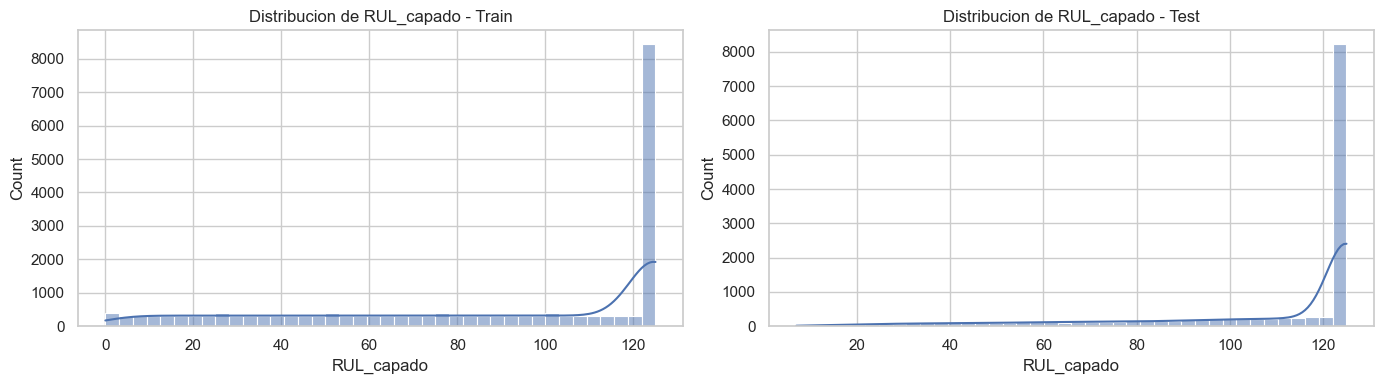

In [4]:
def inspect_dataframe(df: pd.DataFrame, name: str, target_col: str = "RUL_capado") -> None:
    """Imprime una exploracion basica del dataframe."""
    print(f"\n===== {name} =====")
    print(f"Dimensiones: {df.shape}")
    print("\nColumnas:")
    print(df.columns.tolist())
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nNulos por columna:")
    print(df.isna().sum())
    if target_col in df.columns:
        print(f"\nEstadisticos de {target_col}:")
        print(df[target_col].describe())


def find_first_existing_column(columns, candidates):
    """Busca la primera columna existente usando comparacion exacta y case-insensitive."""
    normalized = {col.lower(): col for col in columns}
    for candidate in candidates:
        if candidate in columns:
            return candidate
        if candidate.lower() in normalized:
            return normalized[candidate.lower()]
    raise ValueError(f"No se encontro ninguna columna candidata: {candidates}")


def identify_lstm_columns(df: pd.DataFrame):
    """Identifica columnas de motor, ciclo, objetivo y variables numericas de entrada."""
    unit_col = find_first_existing_column(
        df.columns,
        ["unit_number", "unit", "engine_id", "engine", "id", "motor_id", "n_motor"],
    )
    time_col = find_first_existing_column(
        df.columns,
        ["time_in_cycles", "cycle", "cycles", "time", "ciclo", "ciclos"],
    )
    target_col = find_first_existing_column(df.columns, ["RUL_capado", "rul_capado"])

    excluded_cols = {
        unit_col,
        time_col,
        target_col,
        "RUL",
        "rul",
        "risk_level",
        "risk_level_capped",
    }
    excluded_lower = {col.lower() for col in excluded_cols}

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col.lower() not in excluded_lower]

    if not feature_cols:
        raise ValueError("No se encontraron columnas numericas para usar como features.")

    return unit_col, time_col, target_col, feature_cols


inspect_dataframe(train_df, "TRAIN")
inspect_dataframe(test_df, "TEST")

unit_col, time_col, target_col, feature_cols = identify_lstm_columns(train_df)

print("\nColumnas detectadas")
print(f"Motor:    {unit_col}")
print(f"Ciclo:    {time_col}")
print(f"Objetivo: {target_col}")
print(f"Features numericas ({len(feature_cols)}): {feature_cols}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_df[target_col], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribucion de RUL_capado - Train")
sns.histplot(test_df[target_col], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribucion de RUL_capado - Test")
plt.tight_layout()
plt.show()

## 4. Creacion de secuencias para LSTM

Las secuencias se crean con una ventana deslizante de 30 ciclos. Cada ventana pertenece a un unico motor, por lo que no se mezclan ciclos de motores distintos y se evita leakage temporal entre unidades. La etiqueta de cada secuencia es el `RUL_capado` del ultimo ciclo de la ventana.

In [5]:
sequence_length = 30


def create_lstm_sequences(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    unit_col: str,
    time_col: str,
    sequence_length: int,
):
    """Genera X, y y metadatos respetando la frontera temporal de cada motor."""
    sequences = []
    labels = []
    metadata = []

    ordered_df = df.sort_values([unit_col, time_col]).reset_index(drop=True)

    for unit_id, unit_data in ordered_df.groupby(unit_col, sort=False):
        unit_data = unit_data.sort_values(time_col)

        feature_values = unit_data[feature_cols].to_numpy(dtype=np.float32)
        target_values = unit_data[target_col].to_numpy(dtype=np.float32)
        time_values = unit_data[time_col].to_numpy()

        if len(unit_data) < sequence_length:
            continue

        for start_idx in range(0, len(unit_data) - sequence_length + 1):
            end_idx = start_idx + sequence_length
            last_idx = end_idx - 1

            sequences.append(feature_values[start_idx:end_idx])
            labels.append(target_values[last_idx])
            metadata.append(
                {
                    unit_col: unit_id,
                    time_col: time_values[last_idx],
                }
            )

    X = np.asarray(sequences, dtype=np.float32)
    y = np.asarray(labels, dtype=np.float32)
    metadata_df = pd.DataFrame(metadata)
    return X, y, metadata_df


X_train, y_train, train_metadata = create_lstm_sequences(
    train_df, feature_cols, target_col, unit_col, time_col, sequence_length
)
X_test, y_test, test_metadata = create_lstm_sequences(
    test_df, feature_cols, target_col, unit_col, time_col, sequence_length
)

n_features = X_train.shape[2]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Cada muestra tiene forma: ({sequence_length}, {n_features})")
display(test_metadata.head())

X_train shape: (17731, 30, 16)
y_train shape: (17731,)
X_test shape:  (10196, 30, 16)
y_test shape:  (10196,)
Cada muestra tiene forma: (30, 16)


,unit_number,time_in_cycles
0,1,30
1,1,31
2,2,30
3,2,31
4,2,32


## 5. Construccion del modelo

Se define una arquitectura LSTM de dos capas recurrentes. La primera devuelve secuencias completas para alimentar a la segunda; la segunda produce una representacion final de la ventana temporal. La salida es lineal porque el problema es de regresion.

In [6]:
def build_lstm_model(sequence_length: int, n_features: int) -> tf.keras.Model:
    """Construye y compila el modelo LSTM de regresion para RUL."""
    model = models.Sequential(
        [
            layers.Input(shape=(sequence_length, n_features)),
            layers.LSTM(128, return_sequences=True),
            layers.Dropout(0.3),
            layers.LSTM(64, return_sequences=False),
            layers.Dropout(0.3),
            layers.Dense(32, activation="relu"),
            layers.Dense(1, activation="linear"),
        ]
    )

    model.compile(
        optimizer=optimizers.Adam(),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )
    return model


model = build_lstm_model(sequence_length, n_features)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,761 (491.25 KB)

 Trainable params: 125,761 (491.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento

El entrenamiento usa `validation_split=0.2`, `EarlyStopping` para detener cuando no mejora la perdida de validacion, `ReduceLROnPlateau` para reducir la tasa de aprendizaje y `ModelCheckpoint` para guardar automaticamente el mejor modelo.

In [13]:
best_model_path = MODEL_DIR / "best_lstm_fd001_rul.keras"
final_model_path = MODEL_DIR / "final_lstm_fd001_rul.keras"

training_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=training_callbacks,
    shuffle=False,
    verbose=1,
)

Epoch 1/100
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 177.2580 - mae: 9.9443 - rmse: 13.3093
Epoch 1: val_loss improved from None to 243.71782, saving model to C:\Users\alber\Desktop\TFM_Mantenimiento\lstm\models\best_lstm_fd001_rul.keras

Epoch 1: finished saving model to C:\Users\alber\Desktop\TFM_Mantenimiento\lstm\models\best_lstm_fd001_rul.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 178.3107 - mae: 9.9653 - rmse: 13.3533 - val_loss: 243.7178 - val_mae: 11.8183 - val_rmse: 15.6115 - learning_rate: 6.2500e-05
Epoch 2/100
220/222 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 166.5280 - mae: 9.5735 - rmse: 12.8915
Epoch 2: val_loss did not improve from 243.71782
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 166.1321 - mae: 9.6029 - rmse: 12.8892 - val_loss: 244.7542 - val_mae: 11.7207 - val_rmse: 15.6446 - learning_rate: 6.2500e-05
Epoch 3/100
219/222 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 166.4696 - mae: 9.5969 - rmse: 12.8888
Epoch 3: val_loss did not improve 

## 7. Evaluacion de regresion

Se evalua el modelo sobre test mediante MAE, RMSE y R2. Tambien se generan graficos de entrenamiento, comparacion real vs predicho y residuos.

160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Metricas de regresion en test
MAE:  28.4828
RMSE: 34.8634
R2:   -0.3755


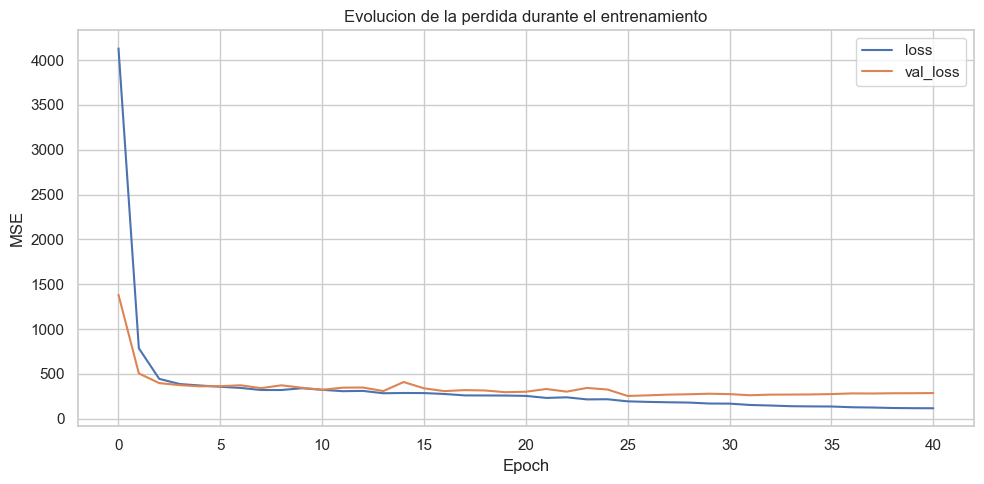

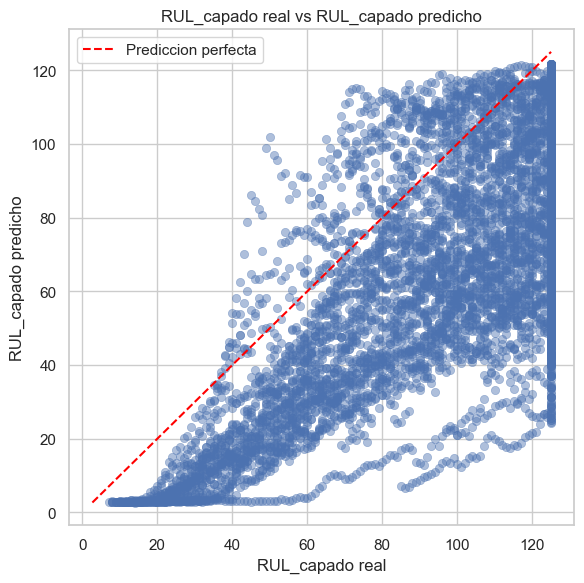

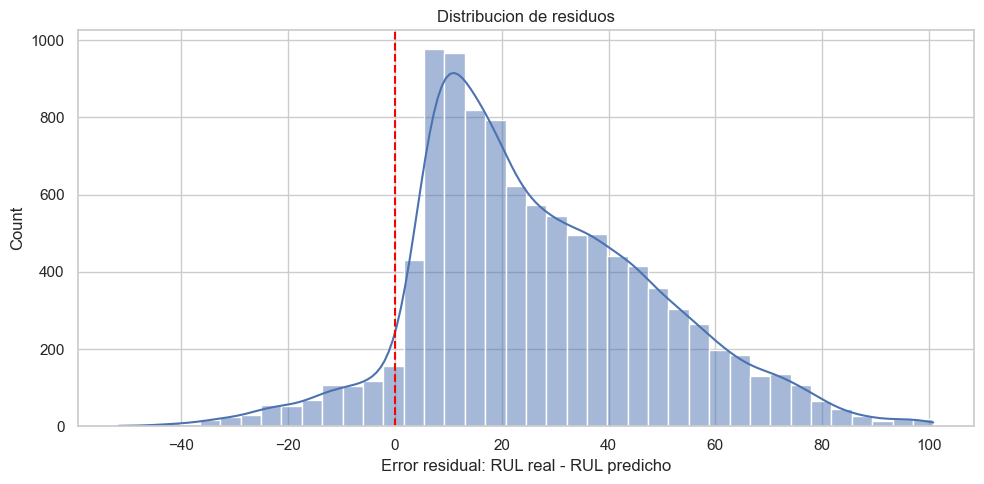

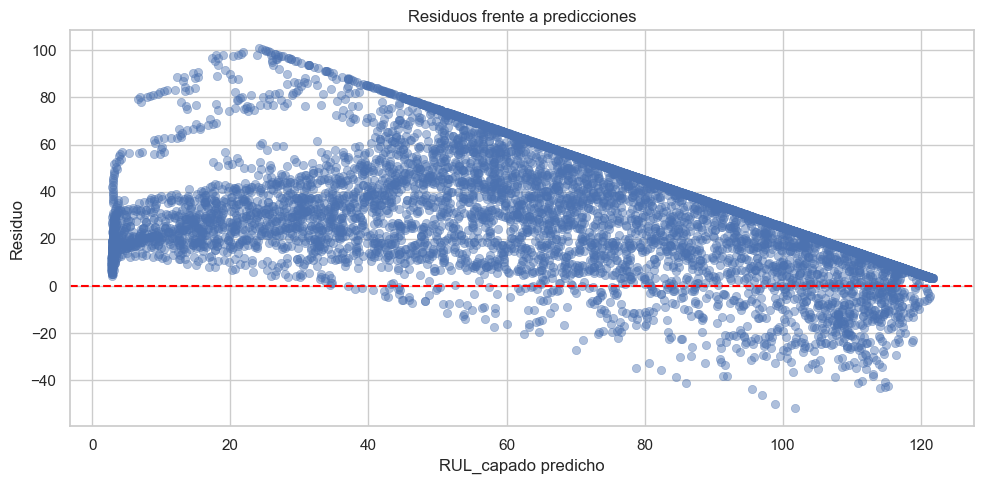

In [8]:
y_pred = model.predict(X_test, batch_size=64).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Metricas de regresion en test")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 5))
plt.plot(history_df["loss"], label="loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Evolucion de la perdida durante el entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.45, edgecolor=None)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--", label="Prediccion perfecta")
plt.title("RUL_capado real vs RUL_capado predicho")
plt.xlabel("RUL_capado real")
plt.ylabel("RUL_capado predicho")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribucion de residuos")
plt.xlabel("Error residual: RUL real - RUL predicho")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.45, edgecolor=None)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuos frente a predicciones")
plt.xlabel("RUL_capado predicho")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()

## 8. Conversion a niveles de riesgo

Los niveles de riesgo se derivan despues de la regresion. Esto conserva la LSTM como modelo principal de prediccion continua de RUL y permite construir una capa posterior de alertas.

In [9]:
def rul_to_risk_level(rul_values):
    """Convierte valores de RUL en niveles de riesgo operativos."""
    values = np.asarray(rul_values)
    return np.select(
        [values <= 30, (values > 30) & (values <= 80), values > 80],
        ["High risk", "Medium risk", "Low risk"],
        default="Unknown",
    )


risk_level_real = rul_to_risk_level(y_test)
risk_level_pred = rul_to_risk_level(y_pred)

risk_distribution = pd.DataFrame(
    {
        "real": pd.Series(risk_level_real).value_counts(),
        "pred": pd.Series(risk_level_pred).value_counts(),
    }
).fillna(0).astype(int)

display(risk_distribution)

,real,pred
Low risk,8116,5350
Medium risk,1748,3666
High risk,332,1180


## 9. Evaluacion de clasificacion derivada

Las metricas de clasificacion se calculan comparando los niveles de riesgo derivados del RUL real y del RUL predicho. No se entrena un clasificador independiente.

Metricas de clasificacion derivada
Accuracy:          0.6301
F1-score weighted: 0.6863

Classification report:
              precision    recall  f1-score   support

   High risk       0.28      1.00      0.44       332
 Medium risk       0.24      0.50      0.33      1748
    Low risk       0.97      0.64      0.77      8116

    accuracy                           0.63     10196
   macro avg       0.50      0.72      0.51     10196
weighted avg       0.83      0.63      0.69     10196



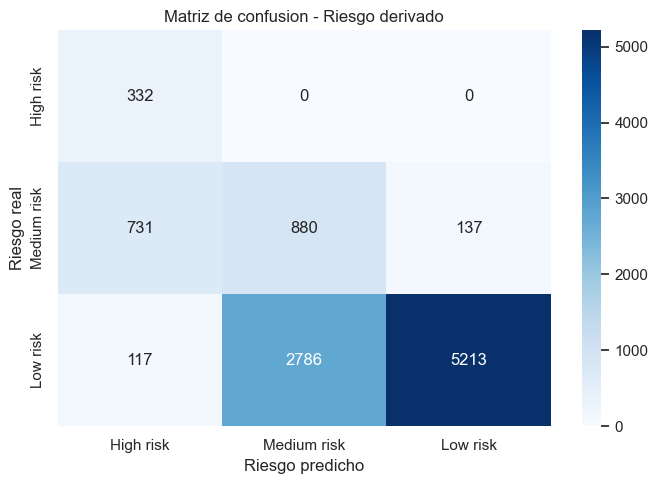

In [10]:
risk_labels = ["High risk", "Medium risk", "Low risk"]

accuracy = accuracy_score(risk_level_real, risk_level_pred)
f1_weighted = f1_score(risk_level_real, risk_level_pred, average="weighted")

print("Metricas de clasificacion derivada")
print(f"Accuracy:          {accuracy:.4f}")
print(f"F1-score weighted: {f1_weighted:.4f}")
print("\nClassification report:")
print(classification_report(risk_level_real, risk_level_pred, labels=risk_labels, zero_division=0))

cm = confusion_matrix(risk_level_real, risk_level_pred, labels=risk_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=risk_labels,
    yticklabels=risk_labels,
)
plt.title("Matriz de confusion - Riesgo derivado")
plt.xlabel("Riesgo predicho")
plt.ylabel("Riesgo real")
plt.tight_layout()
plt.show()

## 10. Exportacion de predicciones

Se guardan las predicciones de test junto con el motor, ciclo, RUL real, RUL predicho, niveles de riesgo y error absoluto. Este CSV puede usarse para analisis posterior, dashboards o trazabilidad del sistema de alertas.

In [11]:
results_df = test_metadata.copy()
results_df = results_df.rename(columns={unit_col: "unit_number", time_col: "time_in_cycles"})
results_df["RUL_real"] = y_test
results_df["RUL_pred"] = y_pred
results_df["risk_level_real"] = risk_level_real
results_df["risk_level_pred"] = risk_level_pred
results_df["error_abs"] = np.abs(results_df["RUL_real"] - results_df["RUL_pred"])

results_path = OUTPUT_DIR / "lstm_fd001_test_predictions.csv"
results_df.to_csv(results_path, index=False)

print(f"Predicciones guardadas en: {results_path}")
display(results_df.head())

Predicciones guardadas en: C:\Users\alber\Desktop\TFM_Mantenimiento\lstm\outputs\lstm_fd001_test_predictions.csv


,unit_number,time_in_cycles,RUL_real,RUL_pred,risk_level_real,risk_level_pred,error_abs
0,1,30,113.0,115.655022,Low risk,Low risk,2.655022
1,1,31,112.0,112.188683,Low risk,Low risk,0.188683
2,2,30,117.0,91.261269,Low risk,Low risk,25.738731
3,2,31,116.0,86.320961,Low risk,Low risk,29.679039
4,2,32,115.0,79.114288,Low risk,Medium risk,35.885712


## 11. Guardado del modelo

El modelo final se guarda en formato `.keras`. Durante el entrenamiento tambien se ha guardado el mejor modelo segun `val_loss` mediante `ModelCheckpoint`.

In [12]:
model.save(str(final_model_path))

print(f"Mejor modelo guardado en: {best_model_path}")
print(f"Modelo final guardado en: {final_model_path}")

Mejor modelo guardado en: C:\Users\alber\Desktop\TFM_Mantenimiento\lstm\models\best_lstm_fd001_rul.keras
Modelo final guardado en: C:\Users\alber\Desktop\TFM_Mantenimiento\lstm\models\final_lstm_fd001_rul.keras


## 12. Conclusion tecnica para el TFM

En este experimento se ha planteado el mantenimiento predictivo como un problema de regresion supervisada sobre series temporales multivariantes. Para cada motor se han construido ventanas deslizantes de 30 ciclos usando exclusivamente sus propias observaciones historicas, evitando mezclar motores y reduciendo el riesgo de leakage temporal.

La LSTM aprende patrones temporales en sensores y condiciones operativas para estimar `RUL_capado`, una version acotada de la vida util restante. Esta acotacion suele estabilizar el entrenamiento al limitar valores extremos de RUL en fases tempranas de vida del motor. Posteriormente, el RUL predicho se transforma en niveles de riesgo (`High risk`, `Medium risk`, `Low risk`) mediante umbrales operativos. De esta forma, el modelo principal conserva una salida continua interpretable, mientras que la capa de alertas permite evaluar el impacto practico con metricas de clasificacion como Accuracy, F1-score y matriz de confusion.

Para documentar los resultados, conviene reportar conjuntamente MAE, RMSE y R2, ya que describen el error de regresion desde perspectivas complementarias, y anadir la matriz de confusion derivada para mostrar si los errores de RUL afectan criticamente a la categorizacion del riesgo de mantenimiento.

## Que adaptar si tus columnas cambian de nombre

- Si cambia el identificador del motor, anade el nuevo nombre a la lista de candidatos de `unit_col` dentro de `identify_lstm_columns`.
- Si cambia la columna temporal, anade el nuevo nombre a la lista de candidatos de `time_col`.
- Si la variable objetivo no se llama `RUL_capado`, anade su nombre real a la lista usada para `target_col`.
- Si hay columnas numericas que no deben entrar como sensores, incluyelas en `excluded_cols`.
- Si hay columnas de sensores codificadas como texto, conviertelas antes a numericas o revisa el preprocesado previo.
- Si quieres probar otro horizonte temporal, modifica `sequence_length`. Recuerda que ventanas mas largas reducen el numero de muestras disponibles por motor.